In [14]:
import h5py
import json
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import torch

from methylseqnet.dataset import BaseHDF5Dataset
from methylseqnet_repro.paths import preprocessed_datasets
from methylseqnet.metrics import pearson_per_task, fisher_mean

In [15]:
atlas_folder = preprocessed_datasets / "atlas"
gm12878_haplotyped_folder = preprocessed_datasets / "gm12878_haplotyped"

# The four AlphaGenome-vs-Borzoi models we're comparing, all evaluated on fold4
# (fold3 was used for the original model-search sweep in model_performances_from_h5.ipynb;
# these are separate fold4 prediction runs kicked off from predict-cell-types-ag-v-bz.sh /
# predict-haplotypes-ag-v-bz.sh).
checkpoints = {
    "Borzoi-0 pretrained + 8M FaRM conditioned": "slurm32260895task0/fold4",
    "Borzoi-0 pretrained + 8M imputed-FaRM unconditioned": "slurm32260895task1/fold4",
    "AlphaGenome rep1 128bp + FaRM conditioned": "slurm37760379task4/fold4",
    "AlphaGenome rep1 128bp + imputed-FaRM unconditioned": "slurm37760379task5/fold4",
}

def collate_fn(batch):
    # Separate your data into different types
    collated_batch = {}
    for key, value in batch[0].items():
        if isinstance(value, str):
            collated_batch[key] = [item[key] for item in batch]
        elif isinstance(value, torch.Tensor):
            collated_batch[key] = torch.stack([item[key] for item in batch])
        elif isinstance(value, np.ndarray):
            collated_batch[key] = np.stack([item[key] for item in batch])
        else:
            raise TypeError(f"Unsupported data type for key {key}: {type(value)}")
    return collated_batch

In [16]:
def plot_metrics(
    metrics_dict: dict[str, dict[str, float]],
    models: list[str] | None = None,
    metrics: list[str] | None = None,
    figsize: tuple[float, float] = (10, 6),
    title: str | None = None,
    ylabel: str | None = None,
    bar_width: float = 0.8,
    ax: plt.Axes | None = None,
    colors: list[str] | None = None,
    hatches: list[str | None] | None = None,
    edgecolors: list[str] | None = None,
):
    """Grouped bar plot: groups = metrics, bars within group = models.

    Parameters
    ----------
    metrics_dict : dict[str, dict[str, float]]
        {model_description: {metric_name: value, ...}, ...}
    models : list[str], optional
        Subset / ordering of model keys to plot. Defaults to all.
    metrics : list[str], optional
        Subset / ordering of metric names to plot. Defaults to all
        metrics present across the selected models.
    """
    # Resolve models and metrics
    if models is None:
        models = list(metrics_dict.keys())
    if metrics is None:
        seen = dict()  # preserves insertion order, deduplicates
        for m in models:
            for k in metrics_dict[m]:
                seen[k] = None
        metrics = list(seen)

    n_models = len(models)
    n_metrics = len(metrics)
    single_width = bar_width / n_models
    x = np.arange(n_metrics)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    if colors is not None and len(colors) != n_models:
        raise ValueError(f"len(colors)={len(colors)} must match len(models)={n_models}")

    if hatches is not None and len(hatches) != n_models:
        raise ValueError(f"len(hatches)={len(hatches)} must match len(models)={n_models}")

    if edgecolors is not None and len(edgecolors) != n_models:
        raise ValueError(f"len(edgecolors)={len(edgecolors)} must match len(models)={n_models}")

    if colors is None:
        cmap = plt.get_cmap("tab10") if n_models <= 10 else plt.get_cmap("tab20")
        colors = [cmap(i) for i in range(n_models)]

    for i, model in enumerate(models):
        offsets = x - bar_width / 2 + single_width * (i + 0.5)
        values = [np.mean(metrics_dict[model].get(metric, 0.0)) for metric in metrics]
        ci_lo = [np.percentile(metrics_dict[model].get(metric, [0.0]), 2.5) for metric in metrics]
        ci_hi = [np.percentile(metrics_dict[model].get(metric, [0.0]), 97.5) for metric in metrics]
        yerr = [
            [m - lo for m, lo in zip(values, ci_lo)],
            [hi - m for m, hi in zip(values, ci_hi)],
        ]
        ax.bar(offsets, values, width=single_width, label=model, color=colors[i],
            hatch=hatches[i] if hatches is not None else None,
            edgecolor=edgecolors[i] if edgecolors is not None else None,
            yerr=yerr, capsize=2, error_kw={"linewidth": 0.8})

    ax.set_xticks(x)
    ax.set_xticklabels([metric.replace('\nPearson correlation','') for metric in metrics], rotation=0, ha="center", fontsize=8)
    ax.legend(title="Model", fontsize=8)
    if title:
        ax.set_title(title)
    if ylabel:
        ax.set_ylabel(ylabel)
    fig.tight_layout()
    return fig, ax

In [17]:
# --- Atlas (short-read: ATAC-seq / CAGE-seq) evaluation, fold4 ---
# Status as of 2026-09-08:
#   slurm32260895task0/fold4  DONE
#   slurm32260895task1/fold4  DONE
#   slurm37760379task4/fold4  STILL RUNNING (job 38630323_2) -- its predictions.h5 is being
#                             actively written right now. Opening an HDF5 file mid-write hangs
#                             (default file locking) rather than raising a clean error, so it's
#                             deliberately left out of atlas_checkpoints below rather than relying
#                             on the try/except. Move it up into atlas_checkpoints once the job
#                             finishes.
#   slurm37760379task5/fold4  DONE

atlas_checkpoints = {
    "Borzoi-0 pretrained + 8M FaRM conditioned": "slurm32260895task0/fold4",
    "Borzoi-0 pretrained + 8M imputed-FaRM unconditioned": "slurm32260895task1/fold4",
    "AlphaGenome rep1 128bp + FaRM conditioned": "slurm37760379task4/fold4",
    "AlphaGenome rep1 128bp + imputed-FaRM unconditioned": "slurm37760379task5/fold4",
}

metrics_dict = {
    model_description: {} for model_description in atlas_checkpoints.keys()
}
num_bootstrapping_trials = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for description, checkpoint in tqdm(atlas_checkpoints.items(), desc="Evaluating checkpoints (atlas)"):
    atlas_h5_file = atlas_folder / checkpoint / "predictions.h5"
    try:
        dataset = BaseHDF5Dataset(
            atlas_h5_file,
            datasets = {"predictions", "tracks"},
            return_specifiers = True,
        )
        io_mappings_df = dataset.get_io_mappings_df()
        with h5py.File(atlas_h5_file, "r") as h5f:
            predictions_by_sample = torch.tensor(h5f["predictions"][:]).to(device)
            tracks_by_sample = torch.tensor(h5f["tracks"][:]).to(device)

        predictions = predictions_by_sample.permute(1, 2, 3, 0).flatten(start_dim=2, end_dim=3)
        tracks = tracks_by_sample.permute(1, 2, 3, 0).flatten(start_dim=2, end_dim=3)

        atac_channels = io_mappings_df[io_mappings_df["data_type"] == "ATAC-seq"]["channel"].tolist()
        cage_channels = io_mappings_df[io_mappings_df["data_type"] == "CAGE-seq"]["channel"].tolist()

        atac_tracks = tracks[:, atac_channels, :].squeeze()
        cage_tracks = tracks[:, cage_channels, :].squeeze()
        mean_subtracted_atac_tracks = atac_tracks - atac_tracks.mean(dim=0, keepdim=True)
        mean_subtracted_cage_tracks = cage_tracks - cage_tracks.mean(dim=0, keepdim=True)

        atac_predictions = predictions[:, atac_channels, :].squeeze()
        cage_predictions = predictions[:, cage_channels, :].squeeze()
        mean_subtracted_atac_predictions = atac_predictions - atac_predictions.mean(dim=0, keepdim=True)
        mean_subtracted_cage_predictions = cage_predictions - cage_predictions.mean(dim=0, keepdim=True)

        atac_pearsons_by_task = [
            pearson_per_task(
                predictions = atac_predictions[..., idx],
                targets = atac_tracks[..., idx],
            )
            for _ in range(num_bootstrapping_trials)
            for idx in [torch.randint(0, atac_tracks.shape[-1], (atac_tracks.shape[-1],), device=device)]
        ]
        cage_pearsons_by_task = [
            pearson_per_task(
                predictions = cage_predictions[..., idx],
                targets = cage_tracks[..., idx],
            )
            for _ in range(num_bootstrapping_trials)
            for idx in [torch.randint(0, cage_tracks.shape[-1], (cage_tracks.shape[-1],), device=device)]
        ]
        mean_subtracteds_atac_pearson_by_task = [
            pearson_per_task(
                predictions = mean_subtracted_atac_predictions[..., idx],
                targets = mean_subtracted_atac_tracks[..., idx],
            )
            for _ in range(num_bootstrapping_trials)
            for idx in [torch.randint(0, mean_subtracted_atac_tracks.shape[-1], (mean_subtracted_atac_tracks.shape[-1],), device=device)]
        ]
        mean_subtracteds_cage_pearson_by_task = [
            pearson_per_task(
                predictions = mean_subtracted_cage_predictions[..., idx],
                targets = mean_subtracted_cage_tracks[..., idx],
            )
            for _ in range(num_bootstrapping_trials)
            for idx in [torch.randint(0, mean_subtracted_cage_tracks.shape[-1], (mean_subtracted_cage_tracks.shape[-1],), device=device)]
        ]

        metrics_dict[description]["ATAC-seq\nPearson correlation"] = [
            fisher_mean(atac_pearson_by_task) for atac_pearson_by_task in atac_pearsons_by_task
        ]
        metrics_dict[description]["CAGE-seq\nPearson correlation"] = [
            fisher_mean(cage_pearson_by_task) for cage_pearson_by_task in cage_pearsons_by_task
        ]
        metrics_dict[description]["Cell-type-differential ATAC-seq\nPearson correlation"] = [
            fisher_mean(mean_subtracted_atac_pearson_by_task) for mean_subtracted_atac_pearson_by_task in mean_subtracteds_atac_pearson_by_task
        ]
        metrics_dict[description]["Cell-type-differential CAGE-seq\nPearson correlation"] = [
            fisher_mean(mean_subtracted_cage_pearson_by_task) for mean_subtracted_cage_pearson_by_task in mean_subtracteds_cage_pearson_by_task
        ]
    except (ValueError, OSError) as e:
        print(f"atlas: checkpoint {checkpoint} not successfully opened. ({e})")

/global/scratch/projects/vector_streetslab/oberon/envs/methylseqnet-ag/lib/python3.12/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Evaluating checkpoints (atlas):   0%|          | 0/4 [00:00<?, ?it/s]

In [18]:
# --- Longread/haplotype (gm12878_haplotyped, fiber-seq / iso-seq) evaluation, fold4 ---
# Status as of 2026-09-08: only slurm32260895task0/fold4 has actually finished.
# slurm32260895task1, slurm37760379task4, and slurm37760379task5 are queued under job 38630325
# (array indices 1-3, pending on fc_streets). Note: predictions.h5 files DO already exist on disk
# for those three -- they're partial leftovers from earlier preempted savio_lowprio attempts, not
# complete/safe data, so this whole block stays commented out (rather than letting the try/except
# below silently read partial/wrong data) until all four finish.
#
# Uncomment and run once slurm32260895task1 / slurm37760379task4 / slurm37760379task5 all show
# COMPLETED for gm12878_haplotyped/fold4.

# longread_checkpoints = {
#     "Borzoi-0 pretrained + 8M FaRM conditioned": "slurm32260895task0/fold4",
#     "Borzoi-0 pretrained + 8M imputed-FaRM unconditioned": "slurm32260895task1/fold4",
#     "AlphaGenome rep1 128bp + FaRM conditioned": "slurm37760379task4/fold4",
#     "AlphaGenome rep1 128bp + imputed-FaRM unconditioned": "slurm37760379task5/fold4",
# }
#
# for description, checkpoint in tqdm(longread_checkpoints.items(), desc="Evaluating checkpoints (longread)"):
#     gm_h5_file = gm12878_haplotyped_folder / checkpoint / "predictions.h5"
#     try:
#         dataset = BaseHDF5Dataset(
#             gm_h5_file,
#             datasets = {"predictions", "tracks"},
#             return_specifiers = True,
#         )
#         io_mappings_df = dataset.get_io_mappings_df()
#         with h5py.File(gm_h5_file, "r") as h5f:
#             predictions_by_sample = torch.tensor(h5f["predictions"][:]).to(device)
#             tracks_by_sample = torch.tensor(h5f["tracks"][:]).to(device)
#             chroms_list = [specifier.decode(encoding="utf-8", errors="strict").split("|")[0].split(":")[0] for specifier in h5f["specifier"][:]]
#
#         chrX_indices = [i for i, chrom in enumerate(chroms_list) if chrom == "chrX"]
#         autosome_indices = [i for i, chrom in enumerate(chroms_list) if chrom != "chrX"]
#
#         predictions = predictions_by_sample.permute(1, 2, 3, 0).flatten(start_dim=2, end_dim=3)
#         predictions_chrX = predictions_by_sample[chrX_indices].permute(1, 2, 3, 0).flatten(start_dim=2, end_dim=3)
#         predictions_autosomes = predictions_by_sample[autosome_indices].permute(1, 2, 3, 0).flatten(start_dim=2, end_dim=3)
#
#         tracks = tracks_by_sample.permute(1, 2, 3, 0).flatten(start_dim=2, end_dim=3)
#         tracks_chrX = tracks_by_sample[chrX_indices].permute(1, 2, 3, 0).flatten(start_dim=2, end_dim=3)
#         tracks_autosomes = tracks_by_sample[autosome_indices].permute(1, 2, 3, 0).flatten(start_dim=2, end_dim=3)
#
#         fiber_channels = io_mappings_df[io_mappings_df["data_type"] == "Fiber-seq"]["channel"].tolist()
#         rna_channels = io_mappings_df[io_mappings_df["data_type"] == "RNA-seq"]["channel"].tolist()
#
#         for subset_name, subset_predictions, subset_tracks in [
#             ("chrX", predictions_chrX, tracks_chrX),
#             ("Autosomes", predictions_autosomes, tracks_autosomes),
#             ("All chr.", predictions, tracks),
#         ]:
#             fiber_tracks = subset_tracks[:, fiber_channels, :][0]
#             rna_tracks = subset_tracks[:, rna_channels, :][0]
#             differential_tracks = subset_tracks[0, ...] - subset_tracks[1, ...]
#             differential_fiber_tracks = differential_tracks[fiber_channels, :]
#             differential_rna_tracks = differential_tracks[rna_channels, :]
#
#             fiber_predictions = subset_predictions[:, fiber_channels, :][0]
#             rna_predictions = subset_predictions[:, rna_channels, :][0]
#             differential_predictions = subset_predictions[0, ...] - subset_predictions[1, ...]
#             differential_fiber_predictions = differential_predictions[fiber_channels, :]
#             differential_rna_predictions = differential_predictions[rna_channels, :]
#
#             fiber_pearson_by_task = [
#                 pearson_per_task(predictions=fiber_predictions[..., idx], targets=fiber_tracks[..., idx])
#                 for _ in range(num_bootstrapping_trials)
#                 for idx in [torch.randint(0, fiber_tracks.shape[-1], (fiber_tracks.shape[-1],), device=device)]
#             ]
#             rna_pearson_by_task = [
#                 pearson_per_task(predictions=rna_predictions[..., idx], targets=rna_tracks[..., idx])
#                 for _ in range(num_bootstrapping_trials)
#                 for idx in [torch.randint(0, fiber_tracks.shape[-1], (fiber_tracks.shape[-1],), device=device)]
#             ]
#             differential_fiber_pearson_by_task = [
#                 pearson_per_task(predictions=differential_fiber_predictions[..., idx], targets=differential_fiber_tracks[..., idx])
#                 for _ in range(num_bootstrapping_trials)
#                 for idx in [torch.randint(0, fiber_tracks.shape[-1], (fiber_tracks.shape[-1],), device=device)]
#             ]
#             differential_rna_pearson_by_task = [
#                 pearson_per_task(predictions=differential_rna_predictions[..., idx], targets=differential_rna_tracks[..., idx])
#                 for _ in range(num_bootstrapping_trials)
#                 for idx in [torch.randint(0, fiber_tracks.shape[-1], (fiber_tracks.shape[-1],), device=device)]
#             ]
#             metrics_dict[description][f"{subset_name}\nFiber-seq\nPearson correlation"] = [
#                 fisher_mean(x) for x in fiber_pearson_by_task
#             ]
#             metrics_dict[description][f"{subset_name}\nIso-seq 5'\nPearson correlation"] = [
#                 fisher_mean(x) for x in rna_pearson_by_task
#             ]
#             metrics_dict[description][f"{subset_name} Haplotype-differential\nFiber-seq\nPearson correlation"] = [
#                 fisher_mean(x) for x in differential_fiber_pearson_by_task
#             ]
#             metrics_dict[description][f"{subset_name} Haplotype-differential\nIso-seq 5'\nPearson correlation"] = [
#                 fisher_mean(x) for x in differential_rna_pearson_by_task
#             ]
#     except (ValueError, OSError) as e:
#         print(f"longread: checkpoint {checkpoint} not successfully opened. ({e})")

In [19]:
# Cache to disk so re-running the plotting cell below doesn't require recomputing bootstraps.
# Distinct filename from the original notebook's metrics.json -- this is a separate, smaller
# comparison (4 models, fold4 only) and shouldn't clobber that cache.
with open("metrics_ag_v_bz_fold4.json", "w") as f:
    json.dump(metrics_dict, f, indent=4)

# with open("metrics_ag_v_bz_fold4.json", "r") as f:
#     metrics_dict = json.load(f)

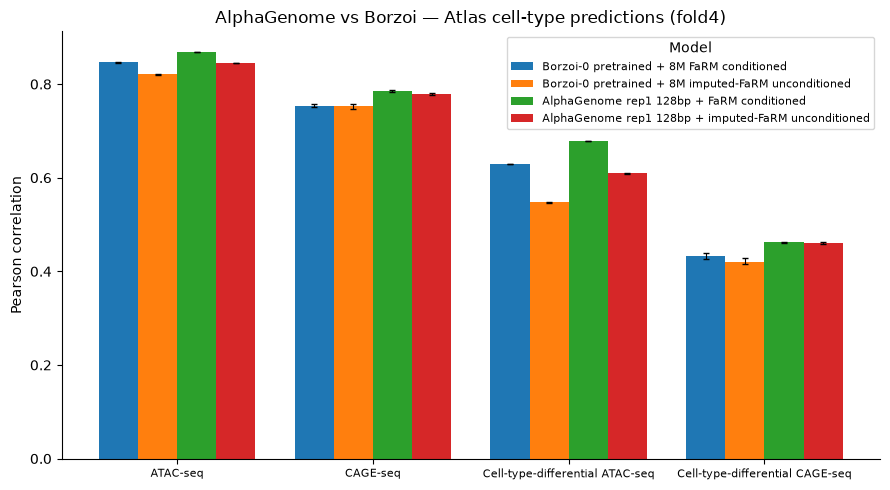

In [21]:
# Single comparison plot across all four models (whichever of the four have been computed
# above -- currently 3/4 atlas, will auto-expand to 4/4 once slurm37760379task4/fold4 finishes
# and gets uncommented in atlas_checkpoints; longread metrics aren't included yet, see note above).
fig, ax = plot_metrics(
    metrics_dict,
    models=list(metrics_dict.keys()),
    title="AlphaGenome vs Borzoi \u2014 Atlas cell-type predictions (fold4)",
    ylabel="Pearson correlation",
    figsize=(9, 5),
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.savefig("pdfs/ag_v_bz_atlas_fold4.pdf")
plt.show()